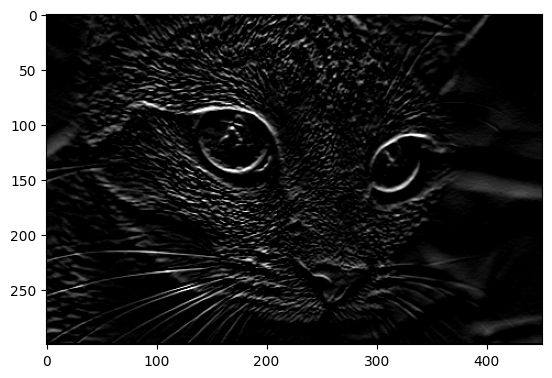

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("../data/benchmarks/cat.png", cv2.IMREAD_GRAYSCALE)

sobel_kernel = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])   # Sobel kernel for edge detection

convolved_image = cv2.filter2D(image, -1, sobel_kernel) # Actual process of Convolution

plt.imshow(convolved_image, cmap='gray')
plt.show()


In [2]:
def box_filt(n):
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be positive odd integer.")
    
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel


In [3]:
def apply_convolution(image_input, kernel):

    row, column = image_input.shape
    filt_size = kernel.shape[0]
    
    pad_size = filt_size // 2

    image_padded = np.pad(image_input, 
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)), 
                          mode='symmetric')
    
    image_output = np.zeros_like(image_input)

    for i in range(row):
        for j in range(column):

            patch_curr = image_padded[i : i + filt_size, j : j + filt_size]
            
            results = kernel * patch_curr
            
            image_output[i, j] = np.sum(results)

    return image_output

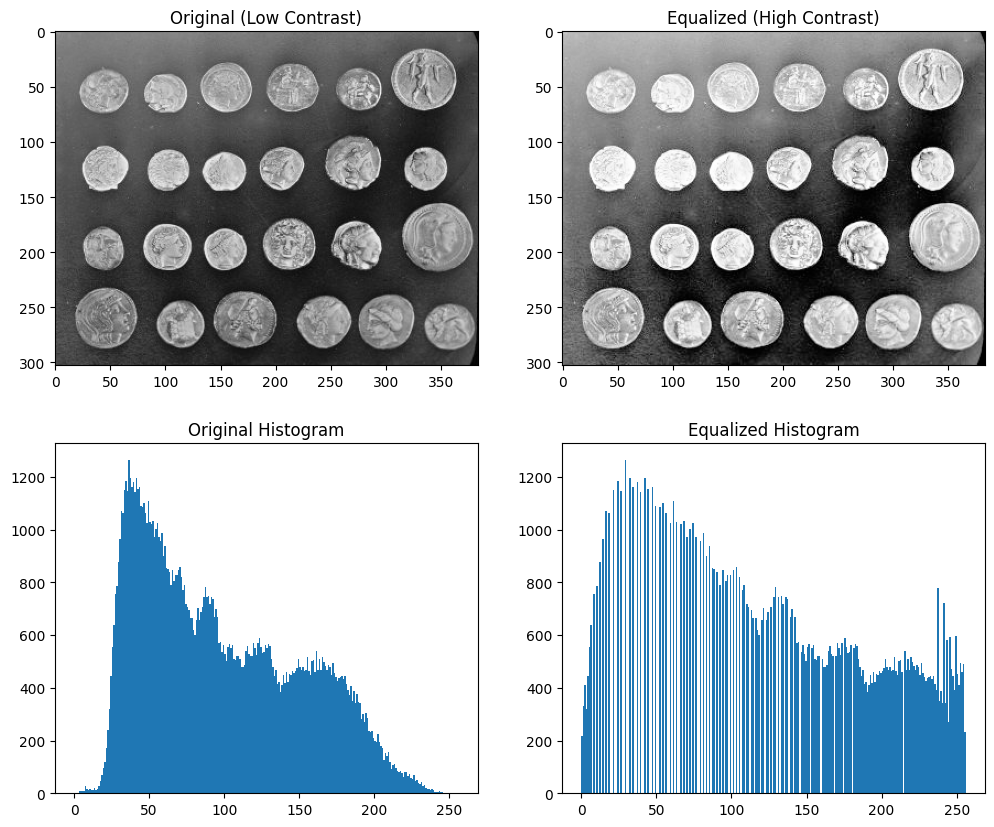

In [9]:
img = cv2.imread("../data/benchmarks/coins.png", 0)

equ = cv2.equalizeHist(img)

plt.figure(figsize=(12, 10))

plt.subplot(221); plt.imshow(img, cmap='gray'); plt.title("Original (Low Contrast)")
plt.subplot(222); plt.imshow(equ, cmap='gray'); plt.title("Equalized (High Contrast)")

plt.subplot(223); plt.hist(img.ravel(), 256, range=[0,256]); plt.title("Original Histogram") 
plt.subplot(224); plt.hist(equ.ravel(), 256, range=[0,256]); plt.title("Equalized Histogram")

plt.show();

Weights for size 5, sigma 1.0
[[0.05448868]
 [0.24420134]
 [0.40261995]
 [0.24420134]
 [0.05448868]] 

Weights for size 11, sigma 2.0
[[0.00881223]
 [0.02714358]
 [0.06511406]
 [0.12164907]
 [0.17699836]
 [0.20056541]
 [0.17699836]
 [0.12164907]
 [0.06511406]
 [0.02714358]
 [0.00881223]]


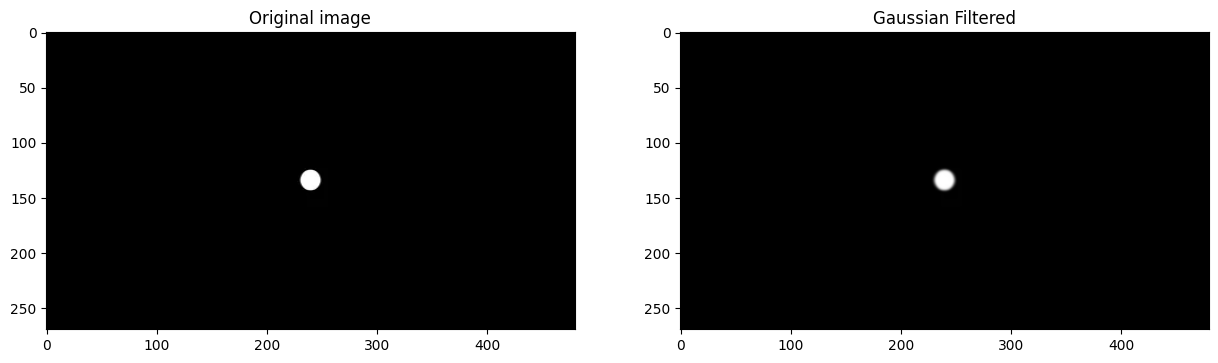

In [24]:
image = cv2.imread("../data/benchmarks/dot.png")

gaussian_blur = cv2.getGaussianKernel(5, 1.0)
gaussian_blur1 = cv2.getGaussianKernel(11, 2.0)

blurred_image = cv2.GaussianBlur(image, (5, 5), sigmaX=0)  # Zero means choose a perfect sigma yourself

print("Weights for size 5, sigma 1.0")
print(gaussian_blur, "\n")

print("Weights for size 11, sigma 2.0")
print(gaussian_blur1)

plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.imshow(image[...,::-1])
plt.title("Original image")

plt.subplot(1,2,2)
plt.imshow(blurred_image[...,::-1])
plt.title("Gaussian Filtered")

plt.show();

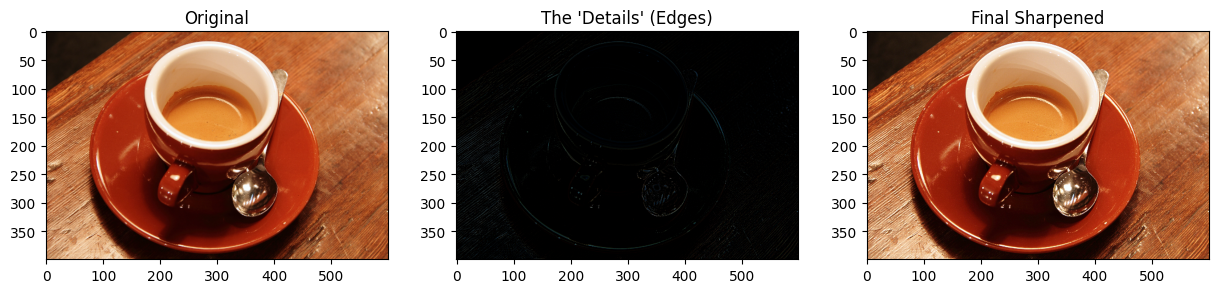

In [ ]:
image = cv2.imread("../data/benchmarks/coffee.png")

filtered_image = cv2.GaussianBlur(image, (5, 5), sigmaX=0)   # Blur the image

details = cv2.subtract(image, filtered_image) # Get the edges

sharpened_image = cv2.addWeighted(image, 1.0, details, 1.5, 0) # Apply those edges to the original image

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(image[...,::-1]); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(details[...,::-1]); plt.title("The 'Details' (Edges)")
plt.subplot(1,3,3); plt.imshow(sharpened_image[...,::-1]); plt.title("Final Sharpened")
plt.show()